# Tensile Test (PMDCo): from machine file to RDF

> **This is notebook 2 of 2.** It assumes you have already worked through
> [Notebook 1](1_tensile_test_pmdco_workflow.ipynb), which explains the PMDCo
> schema structure, the OO-LD format, and SHACL validation using a hand-crafted
> input file. Here, the same pipeline runs end-to-end from a real instrument
> export, with no manual data entry required.

**You only need to edit one cell:** Step 0 below. Everything else is automatic.

**What you get back:**
- An RDF graph with test metadata (conditions, standard, temperature) following
  the [PMDCo measurement pattern](https://github.com/materialdigital/core-ontology/tree/main/patterns/measurement)
  — column annotations identified by `rdfs:label` rather than TTO class IRIs
- A pandas DataFrame with the full time-series data, ready to plot or analyse

```
Instrument export file
  │
  ├─ metadata rows  ──► Transformer ──► OO-LD ──► RDF graph
  │                     (same transform as notebook 1)
  └─ data rows  ─────► pandas DataFrame
```

## PMDCo vs TTO for machine-file processing

| | TTO schema | PMDCo schema (this notebook) |
|---|---|---|
| Process class | `pmdco:PMD_0000974` | `pmdco:PMD_0000974` |
| Column annotations | `a tto:Extension`, `a tto:StandardForce` … | `rdfs:label` only — no class IRI |
| Column lookup | `result.column_iris` (TTO IRI → column name) | `result.column_units` (QUDT unit → column name) |
| SPARQL column query | Must know TTO class IRIs | Uses `rdfs:label` |
| Best for | TTO-aware tooling, cross-repo queries by class | Generic PMDCo tooling, label-based queries |

## Supported file format

This notebook uses the **testXpert III parser** for Zwick/Roell instruments.
For other instruments, swap in a different parser; the rest of the notebook
stays unchanged. See `semantic-transformers/src/semantic_transformers/parsers/`
for available parsers.

## Environment setup

```bash
git clone https://github.com/Semantic-Dataspace/semantic-schemas.git
cd semantic-schemas
python3 -m venv .venv && source .venv/bin/activate
pip install semantic-schemas semantic-transformers jupyterlab
jupyter lab
```

In [1]:
# Install dependencies (run once; skip if already installed)
%pip install -q semantic-schemas semantic-transformers

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json, pathlib, rdflib
from importlib.metadata import version
from semantic_schemas import Schema

HERE   = pathlib.Path().resolve()   # docs/
SCHEMA = HERE.parent                # tensile-test/PMDCo/

pmdco_schema = Schema(SCHEMA)

print("rdflib  ", version("rdflib"))

from semantic_transformers import Transformer
from semantic_transformers.parsers.characterization.tensile_test.testxpert_iii import TestXpertIIIParser

print("semantic-transformers", version("semantic-transformers"))

# Example test file shipped with this schema
csv_file = HERE / 'example_tensile_test.TXT'

rdflib   7.6.0


semantic-transformers 0.1.0


## Step 0: Point to your file

Edit the lines below and run all cells. That is all that is needed for a basic run.

| Variable | What to put here |
|---|---|
| `csv_file` | Path to your Zwick export (`.TXT` or `.csv`) |
| `BASE_IRI` | Base IRI for this dataset; replace with your own namespace |

`test_name` is optional; if omitted the file name is used.

In [3]:
test_name = None   # optional; set to a string to override the file-name default

# Base IRI for this dataset. Relative node IDs (test instance, conditions,
# timeseries dataset) are resolved against this IRI. Replace with your own
# namespace in production, e.g. "https://your-institute.org/tests/".
BASE_IRI = "https://example.org/"

print(f"Using test file : {csv_file.name}")
print(f"File exists     : {csv_file.exists()}")
print(f"Base IRI        : {BASE_IRI}")

Using test file : example_tensile_test.TXT
File exists     : True
Base IRI        : https://example.org/


## Step 1: Parse, transform, and build the RDF graph

The `Transformer` does three things in one call:

1. **Parse**: the Zwick parser reads the export file, separates the metadata
   block from the time-series rows, and maps the metadata to the simplified
   JSON format the schema transform expects.
2. **Transform**: the JSONata expression in `specs/transform.simplified.jsonata`
   converts the simplified JSON into an OO-LD document following the PMDCo
   measurement pattern — `MeasurementDatum` nodes labelled by free text,
   each embedding a `ScalarValueSpecification`.
3. **Build RDF**: the OO-LD document is parsed into an RDF graph.

| JSON field | Ontology IRI |
|---|---|
| `type` (process) | `rdf:type` → `pmdco:PMD_0000974` |
| `realizes` | `BFO_0000055` → evaluant role node (`OBI_0000067`) |
| `has_specified_input` | `OBI_0000293` → specimen (`BFO_0000040`) |
| `has_process_attribute` | `pmdco:PMD_0000009` |
| `measured_properties` | `OBI_0000299` → `obo:IAO_0000109` (datum, labelled) |
| `is_about` (on datum) | `IAO_0000136` → specimen |
| `is_quality_measurement_of` | `IAO_0000221` → quality (`BFO_0000019`) |
| `has_value_spec` | `OBI_0001938` → `obo:OBI_0001931` (SVS) |
| `result_value` | `OBI_0001937` (has_specified_numeric_value) |
| `result_unit` | `IAO_0000039` (has_measurement_unit_label) |
| `specifies_value_of` | `OBI_0001927` → quality |
| `is_about` (on value spec) | `IAO_0000136` → specimen |

In [4]:
transformer = Transformer(
    parser          = TestXpertIIIParser(),
    semantic_schema = SCHEMA,
)

overrides = {}
if test_name:
    overrides['test_name'] = test_name

result = transformer.run(csv_file, base=BASE_IRI, **overrides)

print('OO-LD document (intermediate):')
print(json.dumps(result.oold_doc, indent=2))

OO-LD document (intermediate):
{
  "conforms_to": "https://github.com/semantic-dataspace/semantic-schemas/tree/main/schemas/characterization/step/tensile-test/PMDCo/#v1.0.0",
  "type": "pmdco:PMD_0000974",
  "id": "tensile-test-example-tensile-test",
  "label": "example_tensile_test",
  "realizes": [
    {
      "type": "obo:OBI_0000067",
      "id": "tensile-test-example-tensile-test-evaluant-role",
      "realized_in": "tensile-test-example-tensile-test"
    }
  ],
  "has_specified_input": [],
  "date": "2021-05-19T09:36:00",
  "has_process_attribute": [
    {
      "type": "pmdco:PMD_0000013",
      "id": "tensile-test-example-tensile-test-condition-standard",
      "parameter_label": "Test Standard",
      "parameter_unit": "ISO 6892-1"
    },
    {
      "type": "pmdco:PMD_0000013",
      "id": "tensile-test-example-tensile-test-condition-strain-rate",
      "parameter_label": "Strain Rate",
      "parameter_value": 0.1,
      "parameter_unit": "mm/s"
    },
    {
      "type": "p

## Step 2: Explore the time-series data

The raw measurement columns are in `result.dataframe`, a standard pandas
DataFrame. You can plot, filter, or compute derived quantities (yield strength,
Young's modulus, …) using any tool you like.

Unlike the TTO schema, PMDCo column annotations carry a `rdfs:label` and a
QUDT unit but **no ontology class IRI**. Columns are therefore identified by
their label or by unit rather than by a class such as `tto:Extension`.

In [5]:
df = result.dataframe
print(f'{len(df)} rows  ×  {len(df.columns)} columns\n')
print(df.head(10).to_string(index=False))

82 rows  ×  6 columns

 Prüfzeit  Standardkraft  Traversenweg absolut  Standardweg  Breitenänderung  Dehnung
      0.0            0.0                 0.000        0.000           -0.000     0.00
      0.1          807.6                 0.011        0.010           -0.001     0.01
      0.2         1615.2                 0.023        0.020           -0.001     0.02
      0.3         2422.8                 0.034        0.030           -0.002     0.04
      0.5         3230.4                 0.045        0.040           -0.003     0.05
      0.6         4038.1                 0.056        0.050           -0.004     0.06
      0.7         4845.7                 0.068        0.059           -0.004     0.07
      0.8         5653.3                 0.079        0.069           -0.005     0.09
      0.8         5721.1                 0.081        0.071           -0.005     0.09
      0.8         5032.0                 0.082        0.073           -0.006     0.09


In [6]:
# Semantic annotations stored in the graph — PMDCo uses QUDT unit + rdfs:label.
# There are no TTO class IRIs on the column descriptor nodes.
print(f'{"Column":<25}  QUDT unit')
print('-' * 65)
for col in df.columns:
    unit = (result.column_units or {}).get(col, '—')
    print(f'{col:<25}  {unit}')

Column                     QUDT unit
-----------------------------------------------------------------
Prüfzeit                   http://qudt.org/vocab/unit/SEC
Standardkraft              http://qudt.org/vocab/unit/N
Traversenweg absolut       http://qudt.org/vocab/unit/MilliM
Standardweg                http://qudt.org/vocab/unit/MilliM
Breitenänderung            http://qudt.org/vocab/unit/MilliM
Dehnung                    http://qudt.org/vocab/unit/PERCENT


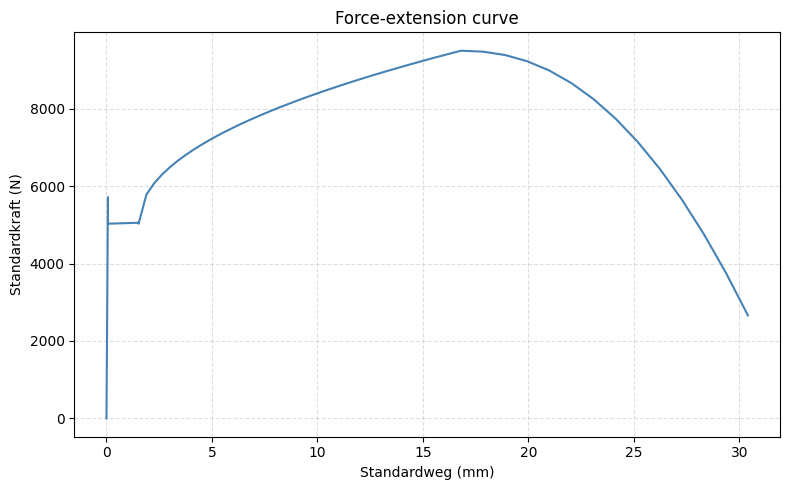

In [7]:
import matplotlib.pyplot as plt

# PMDCo does not assign TTO class IRIs to columns.
# Use QUDT units from the parser to identify column roles.
units = result.column_units or {}

mm_cols    = [c for c, u in units.items() if u and 'MilliM' in str(u)]
force_cols = [c for c, u in units.items() if u and str(u).endswith('/N')]

# Extension column: mm, not crosshead (Traversenweg), not width change (Breiten)
x_col = next(
    (c for c in mm_cols if 'absolut' not in c.lower() and 'breiten' not in c.lower()),
    mm_cols[0] if mm_cols else df.columns[0]
)
y_col = force_cols[0] if force_cols else df.columns[1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df[x_col], df[y_col], color="steelblue", linewidth=1.5)
ax.set_xlabel(f"{x_col} (mm)")
ax.set_ylabel(f"{y_col} (N)")
ax.set_title("Force-extension curve")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Step 3: Inspect the RDF graph

The graph contains:
- The tensile test process node typed as `pmdco:PMD_0000974`
- Process conditions (standard, temperature, strain rate) via `pmdco:PMD_0000009`
- A `dcat:Dataset` node for the time series, linked via `obi:OBI_0000299`
- One column descriptor node per measurement column, annotated with
  `rdfs:label` and QUDT unit — **no TTO class IRI**

In [8]:
flat = result.flat_graph

print(f'Graph contains {len(flat)} triples.\n')
print(flat.serialize(format='turtle'))

Graph contains 68 triples.

@prefix csvw: <http://www.w3.org/ns/csvw#> .
@prefix dcterms: <http://purl.org/dc/terms/> .
@prefix obo: <http://purl.obolibrary.org/obo/> .
@prefix pmdco: <https://w3id.org/pmd/co/> .
@prefix qudt: <http://qudt.org/schema/qudt/> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix uqudt: <http://qudt.org/vocab/unit/> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

<https://example.org/tensile-test-example-tensile-test> a pmdco:PMD_0000974 ;
    rdfs:label "example_tensile_test" ;
    obo:BFO_0000055 <https://example.org/tensile-test-example-tensile-test-evaluant-role> ;
    obo:OBI_0000299 <https://example.org/tensile-test-example-tensile-test/timeseries> ;
    dcterms:conformsTo <https://github.com/semantic-dataspace/semantic-schemas/tree/main/schemas/characterization/step/tensile-test/PMDCo/#v1.0.0> ;
    dcterms:date "2021-05-19T09:36:00"^^xsd:dateTime ;
    pmdco:PMD_0000009 <https://example.org/tensile-test-example-tensile-test-condi

## Step 4: Validate against SHACL shapes

The SHACL shape file `specs/shape.ttl` validates:
- The process node: must have `dcterms:conformsTo` and at least one specimen IRI.
- Each `MeasurementDatum`: must have an `rdfs:label` and a `ScalarValueSpecification`.
- Each `ScalarValueSpecification`: must have a positive numeric value and a
  supported QUDT unit.

> **Note:** if you have not provided a specimen IRI (see the Advanced section
> below), the SHACL result will flag a missing `has_specified_input`. This is
> expected for a basic run; add a specimen IRI before publishing to a knowledge
> graph.

In [9]:
conforms, violations = pmdco_schema.validate(flat)

print(f"Conforms: {conforms}")
for v in violations:
    print(f"  {v}")

Conforms: False
  A TensileTestingProcess must have at least one has_specified_input (the specimen IRI).  [OBI_0000293]
  A TensileTestingProcess must have at least one has_specified_output that is a MeasurementDatum (IAO_0000109).  [OBI_0000299]


## Step 5: Query the graph

SPARQL is the query language for RDF graphs. Because PMDCo uses `rdfs:label`
to identify measurement columns rather than ontology class IRIs, the queries
are simpler — no vocabulary knowledge is required.

The first query inspects the process node and its conditions. The second
lists the column annotations stored in the `dcat:Dataset`.

In [10]:
PMDCO = rdflib.Namespace('https://w3id.org/pmd/co/')

proc_iri = next(flat.subjects(rdflib.RDF.type, PMDCO['PMD_0000974']), None)
if proc_iri:
    print(f'Test IRI : {proc_iri}')
    print(f'Label    : {flat.value(proc_iri, rdflib.RDFS.label)}')
else:
    print('No PMD_0000974 process node found in graph.')

print()

# Process conditions
SPARQL_COND = """
PREFIX pmdco: <https://w3id.org/pmd/co/>
PREFIX rdfs:  <http://www.w3.org/2000/01/rdf-schema#>
PREFIX qudt:  <http://qudt.org/schema/qudt/>

SELECT ?name ?value ?unit
WHERE {
  ?test a pmdco:PMD_0000974 ; pmdco:PMD_0000009 ?cond .
  ?cond rdfs:label ?name .
  OPTIONAL { ?cond qudt:value   ?value . }
  OPTIONAL { ?cond qudt:hasUnit ?unit  . }
}
ORDER BY ?name
"""

rows = list(flat.query(SPARQL_COND))
if rows:
    print(f'{"Condition":<20}  {"Value":>8}  Unit')
    print('-' * 50)
    for r in rows:
        val  = f"{float(r.value):.3g}" if r.value else ''
        unit = str(r.unit) if r.unit else ''
        print(f'{str(r.name):<20}  {val:>8}  {unit}')

print()

# Measurement column annotations — identified by label, no TTO class IRI needed
SPARQL_COLS = """
PREFIX dcat:  <http://www.w3.org/ns/dcat#>
PREFIX rdfs:  <http://www.w3.org/2000/01/rdf-schema#>
PREFIX qudt:  <http://qudt.org/schema/qudt/>

SELECT ?column ?unit
WHERE {
  ?ds a dcat:Dataset ; dcat:distribution ?col .
  ?col rdfs:label ?column .
  OPTIONAL { ?col qudt:hasUnit ?unit . }
}
ORDER BY ?column
"""

rows = list(flat.query(SPARQL_COLS))
if rows:
    print(f'{"Column":<25}  QUDT unit')
    print('-' * 70)
    for r in rows:
        unit = str(r.unit).rsplit('/', 1)[-1] if r.unit else '—'
        print(f'{str(r.column):<25}  {unit}')
else:
    print('No column annotation nodes found.')

Test IRI : https://example.org/tensile-test-example-tensile-test
Label    : example_tensile_test

Condition                Value  Unit
--------------------------------------------------
Gauge Length                80  mm
Pre-load                     2  MPa
Strain Rate                0.1  mm/s
Temperature                 22  °C
Test Standard                   ISO 6892-1

No column annotation nodes found.


## Step 6: Save

Both outputs are saved next to this notebook:

| File | Contents |
|---|---|
| `<stem>.ttl` | RDF graph — process metadata and column descriptors |
| `<stem>.parquet` | Full time-series DataFrame |

Before serializing the RDF, the source CSV and Parquet filenames are written
into the graph as `dcat:accessURL` and `dcat:downloadURL` on the
`dcat:Dataset` node, resolved against `BASE_IRI`. Any system that later reads
the TTL can navigate from the test IRI directly to the raw data:

```sparql
PREFIX pmdco: <https://w3id.org/pmd/co/>
PREFIX obi:   <http://purl.obolibrary.org/obo/OBI_>
PREFIX dcat:  <http://www.w3.org/ns/dcat#>

SELECT ?source ?download
WHERE {
  ?test a pmdco:PMD_0000974 ; obi:0000299 ?ds .
  ?ds a dcat:Dataset .
  OPTIONAL { ?ds dcat:accessURL   ?source   . }
  OPTIONAL { ?ds dcat:downloadURL ?download . }
}
```

In [11]:
stem = pathlib.Path(csv_file).stem

ttl_path     = HERE / f'{stem}.ttl'
parquet_path = HERE / f'{stem}.parquet'

# Register the source CSV and Parquet as dcat:accessURL / dcat:downloadURL.
DCAT = rdflib.Namespace("http://www.w3.org/ns/dcat#")
dataset_node = next(flat.subjects(rdflib.RDF.type, DCAT.Dataset), None)
if dataset_node:
    flat.add((dataset_node, DCAT.accessURL,
              rdflib.URIRef(BASE_IRI + pathlib.Path(csv_file).name)))
    flat.add((dataset_node, DCAT.downloadURL,
              rdflib.URIRef(BASE_IRI + parquet_path.name)))

flat.serialize(destination=str(ttl_path), format='turtle')
print(f'RDF written to       {stem}.ttl')

try:
    df.to_parquet(parquet_path, index=False)
    print(f'DataFrame written to {stem}.parquet')
except ImportError:
    csv_path = HERE / f'{stem}_timeseries.csv'
    df.to_csv(csv_path, index=False)
    print(f'DataFrame written to {stem}_timeseries.csv  (install pyarrow for Parquet)')

RDF written to       example_tensile_test.ttl
DataFrame written to example_tensile_test.parquet


## Summary

| Step | What happens |
|---|---|
| 0 | Point to your file and set the base IRI |
| 1 | testXpert III parser reads the file; Transformer maps metadata to RDF via the PMDCo schema |
| 2 | Time-series DataFrame is ready for analysis and plotting |
| 3 | RDF graph shows the semantic structure (no TTO class IRIs on columns) |
| 4 | SHACL validation confirms structural correctness |
| 5 | SPARQL queries extract conditions and column annotations using `rdfs:label` |
| 6 | Source CSV and Parquet paths registered in graph; both files saved |

---

## Advanced: linking to a specimen

In a knowledge graph, a tensile test is linked to the specimen it consumed.
If you have registered your specimen and know its IRI, add it to the
overrides dict in Step 1:

```python
result = transformer.run(
    csv_file,
    base         = BASE_IRI,
    specimen_iri = 'https://your-institute.org/specimens/my-specimen-1',
)
```

Without a `specimen_iri`, the graph is structurally valid for exploration but
the SHACL validation will flag a missing `has_specified_input`. Add a real IRI
before publishing to a triple store.

---

## Advanced: configuring the testXpert III parser

testXpert III software versions and machine templates vary: the metadata block
may have a different number of rows, use different label strings, or be
localised to another language. Create a small config YAML describing how your
file differs from the default:

```yaml
# parser_config.yaml
metadata_rows: 15            # rows before the column-header row (default: 20)
strain_rate_label: null      # null = skip
meta_field_map:
  Temperature: temperature
  Standard:    test_standard
  Speed:       strain_rate
```

Then pass it to the `Transformer`:

```python
transformer = Transformer(
    parser          = TestXpertIIIParser.from_config("parser_config.yaml"),
    semantic_schema = SCHEMA,
)
```

---

## Further reading

- [Notebook 1: hand-crafted JSON to RDF](1_tensile_test_pmdco_workflow.ipynb)
- [TTO variant, notebook 2](../../TTO/docs/2_tensile_test_csv_workflow.ipynb) — same pipeline with TTO class annotations on columns
- [PMDCo measurement pattern](https://github.com/materialdigital/core-ontology/tree/main/patterns/measurement)
- [semantic-transformers](../../../../semantic-transformers/) — the library powering this notebook
- [Schema format reference](../../../../docs/3_schema-format.md)